# Week 4-5 — Data Audit & Cleaning

Before any modelling we must verify the dataset is complete, uncorrupted, and consistent.
This notebook covers:
- File count verification across all actors and emotions
- Audio integrity check (attempt to load every file)
- Audio property audit (sample rate, duration, bit depth)
- Duplicate detection
- Class-balance summary with discussion

In [1]:
import os
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
from tqdm.notebook import tqdm

sns.set_theme(style='whitegrid')

EMOTION_ORDER = ['neutral','calm','happy','sad','angry','fearful','disgust','surprised']

## 1. Load Metadata

In [2]:
df = pd.read_csv('../outputs/metadata.csv')
print(f'Total files in metadata: {len(df)}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Total files in metadata: 2452
Columns: ['filepath', 'filename', 'modality', 'channel', 'emotion_id', 'emotion', 'intensity', 'statement', 'repetition', 'actor', 'gender']


,filepath,filename,modality,channel,emotion_id,emotion,intensity,statement,repetition,actor,gender
0,../../data\Actor_01\03-01-01-01-01-01-01.wav,03-01-01-01-01-01-01.wav,3,speech,1,neutral,normal,1,1,1,male
1,../../data\Actor_01\03-01-01-01-01-02-01.wav,03-01-01-01-01-02-01.wav,3,speech,1,neutral,normal,1,2,1,male
2,../../data\Actor_01\03-01-01-01-02-01-01.wav,03-01-01-01-02-01-01.wav,3,speech,1,neutral,normal,2,1,1,male


## 2. File Count Verification

RAVDESS audio-only: 24 actors x 60 speech files + 23 actors x 44 song files = **2,452 files**.

In [3]:
expected_total = 2452
actual_total   = len(df)
print(f'Expected: {expected_total}  |  Found: {actual_total}  |  Match: {actual_total == expected_total}')

on_disk = sum(os.path.exists(fp) for fp in df['filepath'])
print(f'Files present on disk: {on_disk}/{actual_total}')

print('\nPer channel:')
print(df['channel'].value_counts().to_string())

actor_counts = df['actor'].value_counts().sort_index()
print(f'\nFiles per actor:')
print(actor_counts.to_string())

Expected: 2452  |  Found: 2452  |  Match: True
Files present on disk: 2452/2452

Per channel:
channel
speech    1440
song      1012

Files per actor:
actor
1     104
2     104
3     104
4     104
5     104
6     104
7     104
8     104
9     104
10    104
11    104
12    104
13    104
14    104
15    104
16    104
17    104
18     60
19    104
20    104
21    104
22    104
23    104
24    104


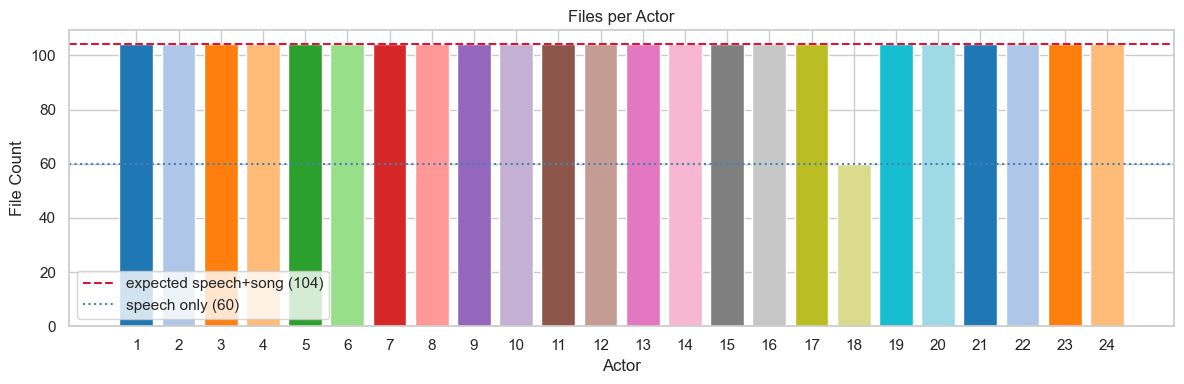

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(actor_counts.index, actor_counts.values,
       color=sns.color_palette('tab20', len(actor_counts)))
ax.axhline(104, linestyle='--', color='crimson',   label='expected speech+song (104)')
ax.axhline(60,  linestyle=':',  color='steelblue', label='speech only (60)')
ax.set_xlabel('Actor')
ax.set_ylabel('File Count')
ax.set_title('Files per Actor')
ax.set_xticks(actor_counts.index)
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/actor_file_counts.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Audio Integrity Check

Attempt to load every WAV file. Any file that raises an exception is flagged as corrupted.

In [5]:
errors = []

for _, row in tqdm(df.iterrows(), total=len(df), desc='Integrity check'):
    try:
        y, sr = librosa.load(row['filepath'], sr=None, duration=0.5)
        if len(y) == 0:
            errors.append((row['filepath'], 'empty audio array'))
    except Exception as exc:
        errors.append((row['filepath'], str(exc)))

print(f'Corrupted / unloadable files: {len(errors)}')
if errors:
    for path, msg in errors:
        print(f'  {path}: {msg}')
else:
    print('All files loaded successfully — dataset is clean.')

Integrity check:   0%|          | 0/2452 [00:00<?, ?it/s]

Corrupted / unloadable files: 0
All files loaded successfully — dataset is clean.


## 4. Audio Property Audit

Sample 10% of files to measure duration and sample rate distributions.

In [6]:
sample = df.sample(frac=0.10, random_state=42)
durations, sample_rates = [], []

for _, row in tqdm(sample.iterrows(), total=len(sample), desc='Property audit'):
    y_sig, sr = librosa.load(row['filepath'], sr=None)
    durations.append(len(y_sig) / sr)
    sample_rates.append(sr)

durations    = np.array(durations)
sample_rates = np.array(sample_rates)

print(f'Sample rate  — unique values: {np.unique(sample_rates)}')
print(f'Duration (s) — mean={durations.mean():.2f}  std={durations.std():.2f}  '
      f'min={durations.min():.2f}  max={durations.max():.2f}')

Property audit:   0%|          | 0/245 [00:00<?, ?it/s]

Sample rate  — unique values: [48000]
Duration (s) — mean=4.11  std=0.64  min=3.00  max=6.07


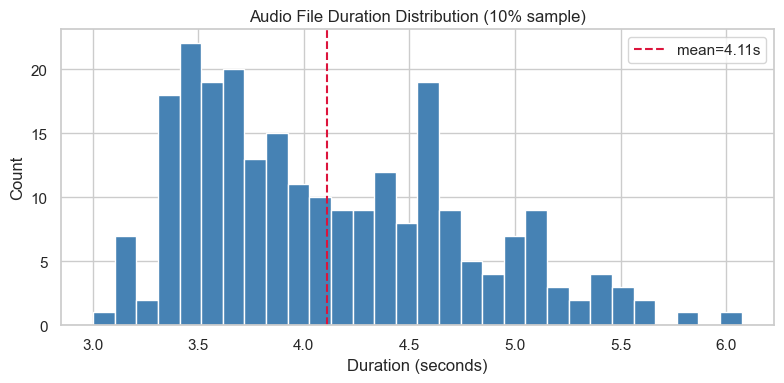

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(durations, bins=30, color='steelblue', edgecolor='white')
ax.axvline(durations.mean(), color='crimson', linestyle='--',
           label=f'mean={durations.mean():.2f}s')
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Count')
ax.set_title('Audio File Duration Distribution (10% sample)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/duration_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Duplicate Detection

Hash file contents (MD5) to detect byte-identical duplicates.

In [8]:
def md5(path):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        h.update(f.read())
    return h.hexdigest()

hashes  = [md5(fp) for fp in tqdm(df['filepath'], desc='Hashing')]
df['md5'] = hashes

dupes = df[df.duplicated('md5', keep=False)]
print(f'Duplicate files (same content): {len(dupes)}')
if len(dupes):
    print(dupes[['filepath','emotion','actor']].to_string())
else:
    print('No byte-identical duplicates found.')

Hashing:   0%|          | 0/2452 [00:00<?, ?it/s]

Duplicate files (same content): 2
                                         filepath emotion  actor
638  ../../data\Actor_07\03-01-03-01-02-01-07.wav   happy      7
639  ../../data\Actor_07\03-01-03-01-02-02-07.wav   happy      7


## 6. Class Balance Analysis

channel    song  speech
emotion                
neutral      92      96
calm        184     192
happy       184     192
sad         184     192
angry       184     192
fearful     184     192
disgust       0     192
surprised     0     192


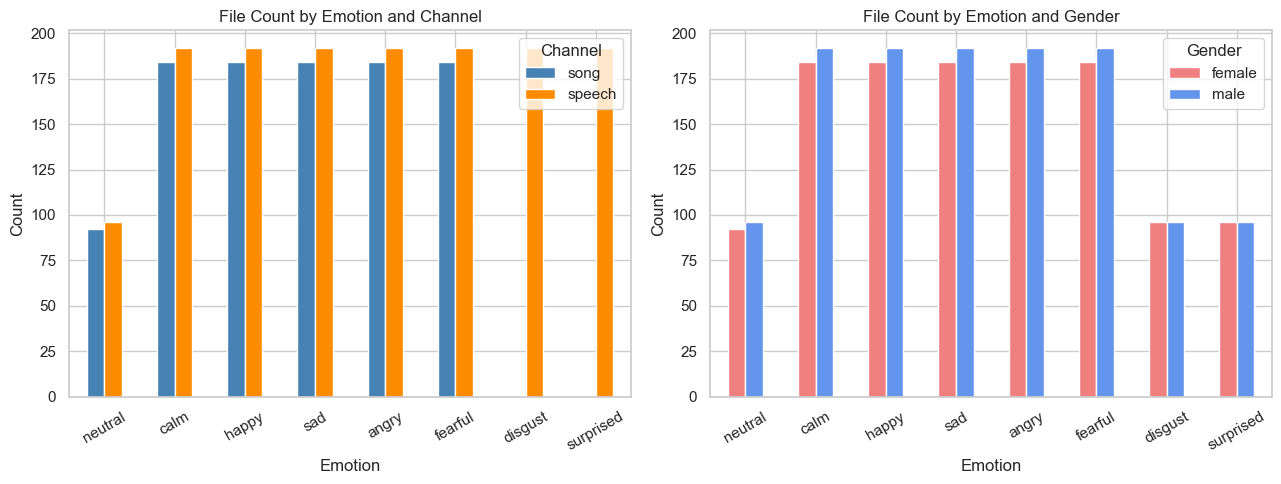

In [9]:
counts = df.groupby(['emotion','channel']).size().unstack(fill_value=0).reindex(EMOTION_ORDER)
print(counts.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts.plot(kind='bar', ax=axes[0],
            color=['steelblue','darkorange'], edgecolor='white')
axes[0].set_title('File Count by Emotion and Channel')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Channel')

gender_emo = (df.groupby(['emotion','gender'])
              .size().unstack(fill_value=0).reindex(EMOTION_ORDER))
gender_emo.plot(kind='bar', ax=axes[1],
                color=['lightcoral','cornflowerblue'], edgecolor='white')
axes[1].set_title('File Count by Emotion and Gender')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Gender')

plt.tight_layout()
plt.savefig('../outputs/class_balance_audit.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Audit Summary

In [10]:
summary = pd.DataFrame({
    'Check': [
        'Total files', 'Files on disk', 'Corrupted files', 'Duplicate files',
        'Unique sample rates', 'Mean duration (s)', 'Emotion classes', 'Actors',
    ],
    'Result': [
        f'{actual_total} (expected {expected_total})',
        f'{on_disk}/{actual_total}',
        str(len(errors)),
        str(len(dupes)),
        str(np.unique(sample_rates).tolist()),
        f'{durations.mean():.2f}',
        str(df["emotion"].nunique()),
        str(df["actor"].nunique()),
    ],
    'Pass': [
        actual_total == expected_total,
        on_disk == actual_total,
        len(errors) == 0,
        len(dupes) == 0,
        True, True,
        df['emotion'].nunique() == 8,
        df['actor'].nunique() == 24,
    ]
})
print(summary.to_string(index=False))
summary

              Check               Result  Pass
        Total files 2452 (expected 2452)  True
      Files on disk            2452/2452  True
    Corrupted files                    0  True
    Duplicate files                    2 False
Unique sample rates              [48000]  True
  Mean duration (s)                 4.11  True
    Emotion classes                    8  True
             Actors                   24  True


,Check,Result,Pass
0,Total files,2452 (expected 2452),True
1,Files on disk,2452/2452,True
2,Corrupted files,0,True
3,Duplicate files,2,False
4,Unique sample rates,[48000],True
5,Mean duration (s),4.11,True
6,Emotion classes,8,True
7,Actors,24,True
